In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

#Carga del dataset desde archivo local
df = pd.read_csv('EDA_Penguins_grupo4/02_limpieza/penguins_limpio.csv')

1. Pairplot básico

sns.pairplot(df[['precio', 'cantidad', 'descuento']])
plt.show()

¿Qué hace esto?
• 	Toma las columnas precio, cantidad y descuento.
• 	Genera todas las combinaciones posibles de gráficos de dispersión entre ellas:
        • 	precio vs cantidad
        • 	precio vs descuento
        • 	cantidad vs descuento
• 	En la diagonal te muestra la distribución de cada variable (histograma o KDE).
¿Para qué sirve?
• 	Ver si dos variables están correlacionadas.
• 	Detectar relaciones lineales o curvas.
• 	Ver si hay grupos o patrones raros.
• 	Identificar outliers.


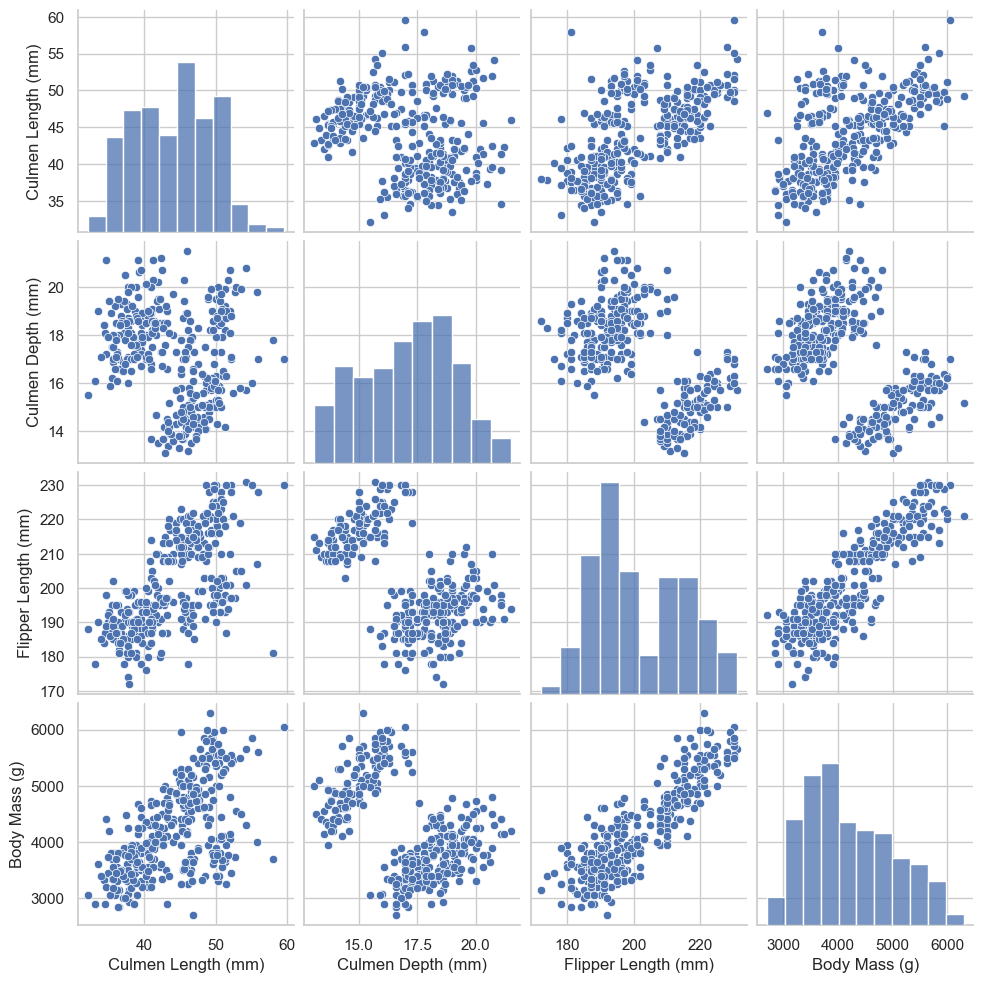

In [6]:
# Pairplot: Múltiples relaciones entre variables numericas.

# Ver todas las combinaciones
sns.pairplot(df[['Culmen Length (mm)', 'Culmen Depth (mm)', "Flipper Length (mm)", "Body Mass (g)"]])
plt.show()

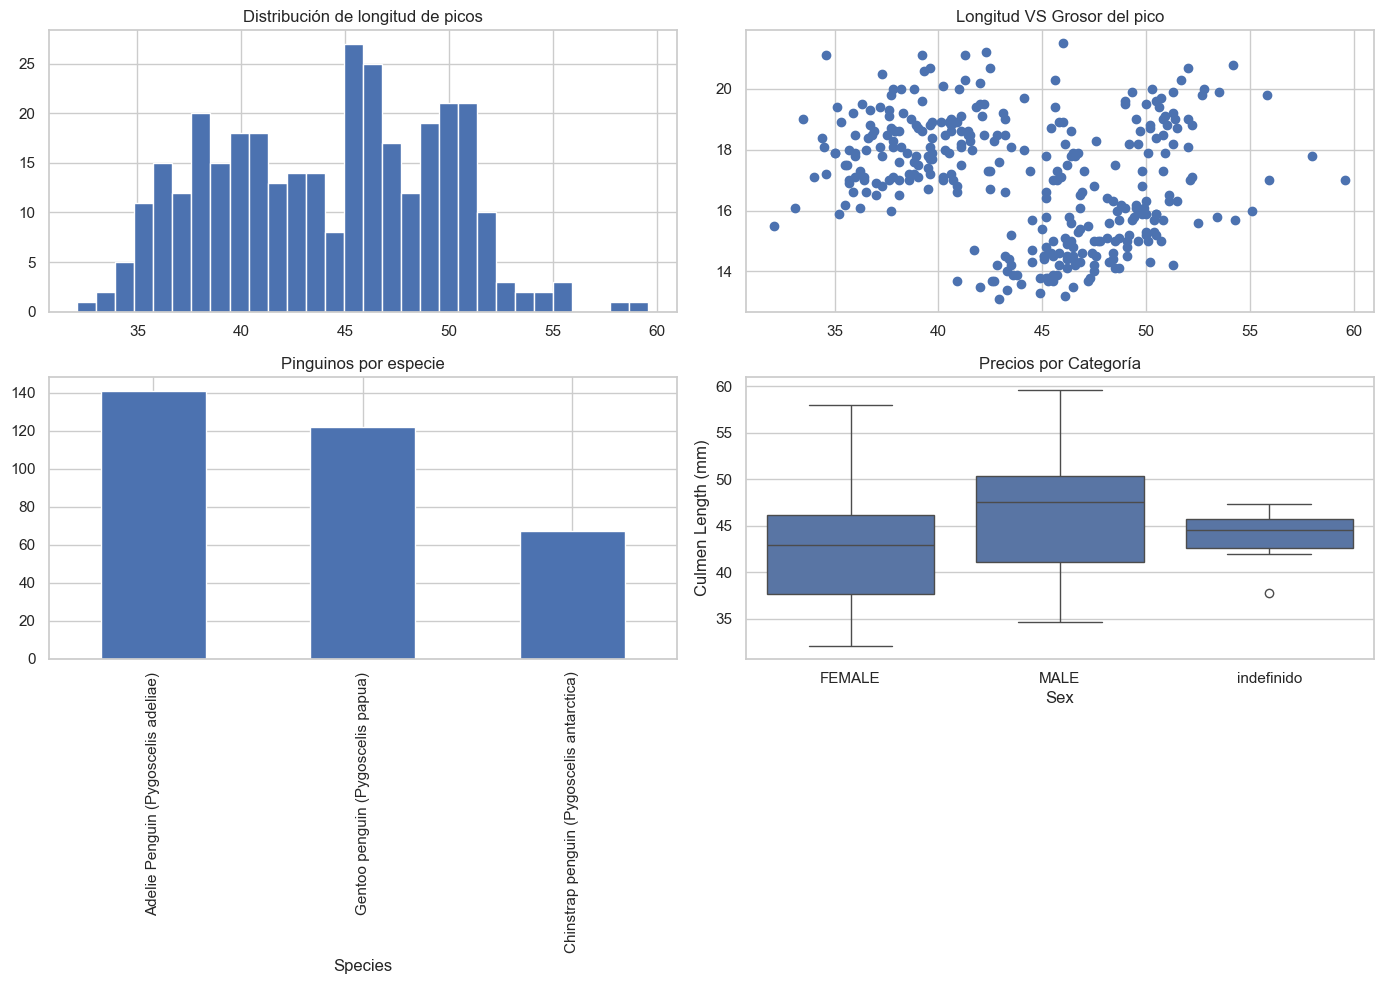

In [ ]:
# Subplots: Múltiples gráficos
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

"""Esto crea:
- una figura (fig)
- una cuadrícula de 2 filas × 2 columnas de gráficos (axes)
- cada celda es un gráfico independiente
- tamaño total: 14×10 pulgadas
Visualmente:
+-----------+-----------+
| axes[0,0] | axes[0,1] |
+-----------+-----------+
| axes[1,0] | axes[1,1] |
+-----------+-----------+
"""

# Gráfico 1
axes[0, 0].hist(df['Culmen Length (mm)'], bins=30)
axes[0, 0].set_title('Distribución de longitud de picos')

""" Esto significa:
- En la posición fila 0, columna 0 (arriba a la izquierda)
- Dibuja un histograma de la columna Culmen Length (mm)
- Con 30 barras (bins=30)
- Le pone el título “Distribución de Precios”
"""

# Gráfico 2
axes[0, 1].scatter(df['Culmen Length (mm)'], df['Culmen Depth (mm)'])
axes[0, 1].set_title('Longitud VS Grosor del pico')

"""Sirve para ver si existe relación entre ambas variables:
- ¿A mayor longitud, mayor grosor?
- ¿Hay patrones?
- ¿Hay outliers?
"""

# Gráfico 3
df['Species'].value_counts().plot(kind='bar', ax=axes[1, 0])
axes[1, 0].set_title('Pinguinos por especie')

"""Esto hace tres cosas:
✔ 1. df['categoria'].value_counts()
Cuenta cuántos productos hay en cada categoría.
✔ 2. .plot(kind='bar')
Dibuja un gráfico de barras con esos conteos.
✔ 3. ax=axes[1, 0]
Le dice a pandas/matplotlib que ese gráfico debe colocarse en ese subplot concreto.
"""

# Gráfico 4
sns.boxplot(x='Sex', y='Culmen Length (mm)', data=df, ax=axes[1, 1])
axes[1, 1].set_title('Precios por Categoría')

"""Esto genera un boxplot donde:
- Eje X → (variable categórica)
- Eje Y → (variable numérica)

¿Qué muestra un boxplot?
Para cada categoría:
- mediana
- cuartiles (Q1 y Q3)
- rango intercuartílico (IQR)
- bigotes (valores dentro de 1.5×IQR)
- outliers (puntos fuera del rango)
Es una forma muy potente de comparar precios entre categorías.

"""

plt.tight_layout() # Esto evita que los gráficos se solapen entre sí. Ajusta márgenes y separaciones automáticamente.

plt.show() 

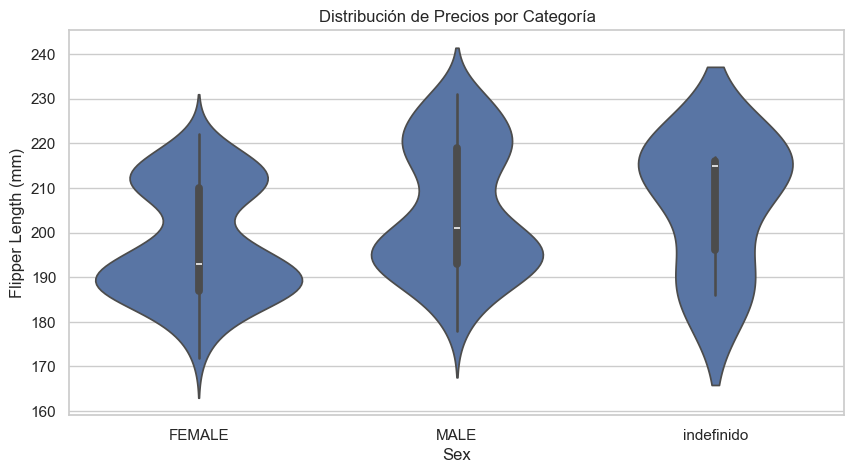

' sns.violinplot(): Crea un violin plot, que muestra:\n- la distribución completa de precio dentro de cada categoria\n- la densidad (zonas más anchas = más datos)\n- la mediana (línea blanca en el centro)\n- los cuartiles (marcas internas)\n- posibles asimetrías o colas largas\n- si hay multimodalidad (dos picos en la distribución)\nEs más informativo que un boxplot cuando quieres ver la forma real de la distribución.\n'

In [9]:
# Violin plot
sns.violinplot(x='Sex', y='Flipper Length (mm)', data=df)
plt.title('Distribución de Precios por Categoría')
plt.show()

""" sns.violinplot(): Crea un violin plot, que muestra:
- la distribución completa de precio dentro de cada categoria
- la densidad (zonas más anchas = más datos)
- la mediana (línea blanca en el centro)
- los cuartiles (marcas internas)
- posibles asimetrías o colas largas
- si hay multimodalidad (dos picos en la distribución)
Es más informativo que un boxplot cuando quieres ver la forma real de la distribución.
"""

Cómo leer cada violín
Piensa en cada violín como un mapa de densidad:
• 	La parte ancha = donde hay más pingüinos con esa longitud de aleta
• 	La parte estrecha = valores menos frecuentes
• 	La línea blanca central = la mediana
• 	La caja interna = los cuartiles (Q1 y Q3)
• 	La forma completa = la distribución real (simétrica, sesgada, con dos picos, etc.)

¿Qué te está diciendo este gráfico?
✔ 1. Comparación entre sexos
Puedes ver si:
• 	los machos tienen aletas más largas que las hembras
• 	las hembras tienen una distribución más estrecha o más amplia
• 	el grupo “indefinido” tiene menos datos (normal en este dataset)
✔ 2. Variabilidad
Si un violín es:
• 	muy ancho → mucha variabilidad
• 	muy estrecho → valores muy parecidos entre sí
✔ 3. Diferencias en la forma
Por ejemplo:
• 	si un violín tiene “dos barrigas”, hay dos grupos dentro de esa categoría
• 	si está desplazado hacia arriba, ese sexo tiene aletas más largas
• 	si está más abajo, tiene aletas más cortas

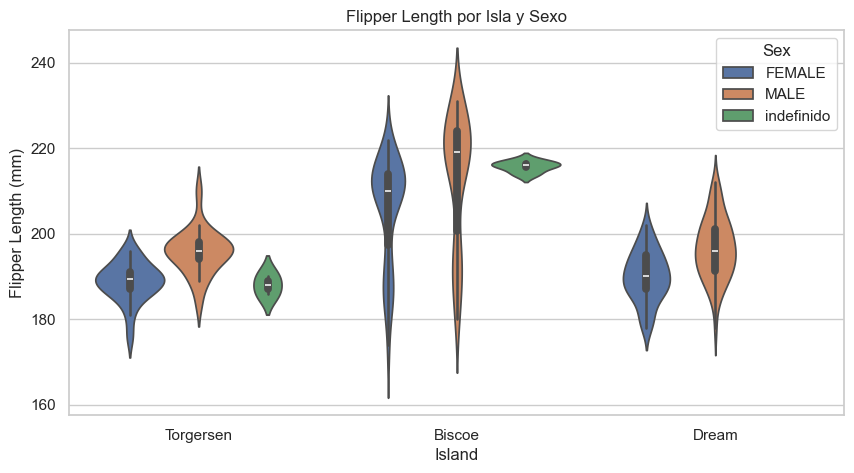

'Muestra la distribución de la longitud de la aleta por isla, separada por sexo.\n¿Qué te da este gráfico?\n- Cada isla tiene un violín.\n- Dentro de cada violín, se separa por sexo (FEMALE vs MALE).\n- Puedes ver si en una isla los machos tienen aletas más largas que las hembras, etc.\nEs muy visual y perfecto para 3 variables.\n'

In [ ]:
sns.violinplot(
    data=df,
    x='Island',
    y='Flipper Length (mm)',
    hue='Sex',
    split=False
)
plt.title('Flipper Length por Isla y Sexo')
plt.show()

"""Muestra la distribución de la longitud de la aleta por isla, separada por sexo.
¿Qué te da este gráfico?
- Cada isla tiene un violín.
- Dentro de cada violín, se separa por sexo (FEMALE vs MALE).
- Puedes ver si en una isla los machos tienen aletas más largas que las hembras, etc.
Es muy visual y perfecto para 3 variables.

✔ split=True
Fusiona ambos violines en uno solo, partido por la mitad:
- lado izquierdo → un sexo
- lado derecho → el otro sexo

"""

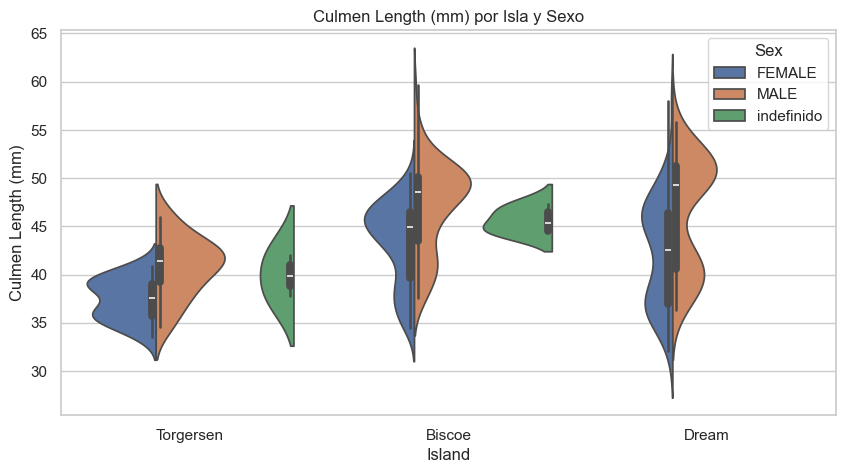

In [20]:
sns.violinplot(
    data=df,
    x='Island',
    y='Culmen Length (mm)',
    hue='Sex',
    split=True
)
plt.title('Culmen Length (mm) por Isla y Sexo')
plt.show()

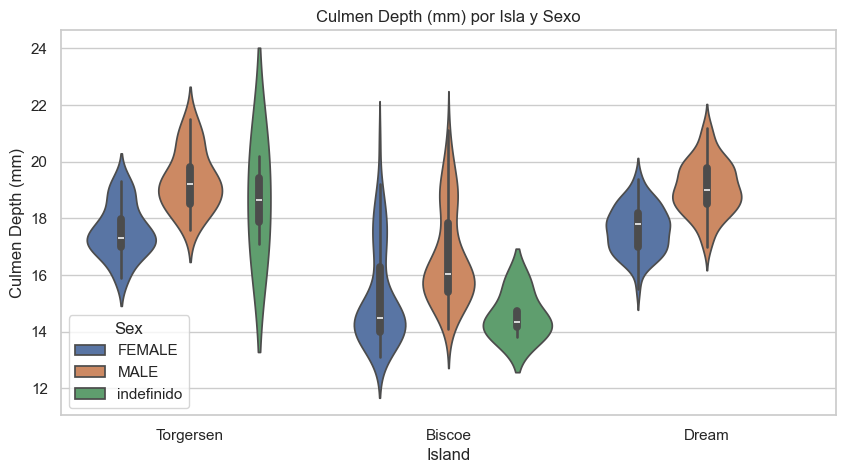

In [18]:
sns.violinplot(
    data=df,
    x='Island',
    y='Culmen Depth (mm)',
    hue='Sex',
    split=False
)
plt.title('Culmen Depth (mm) por Isla y Sexo')
plt.show()

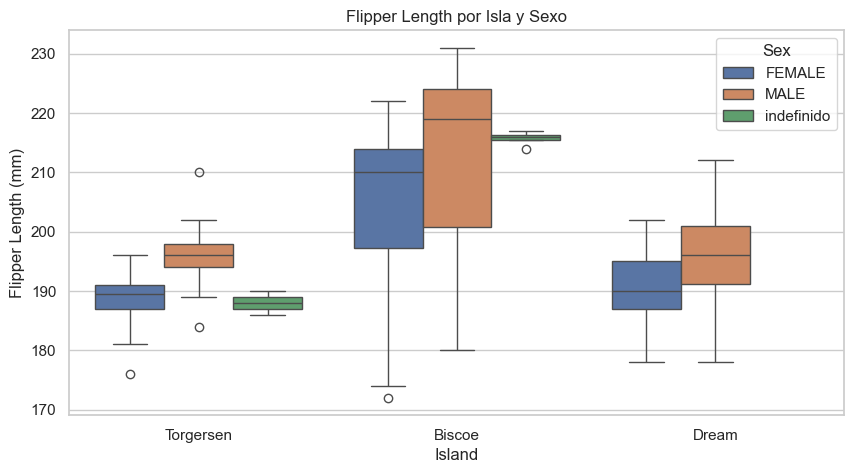

In [11]:
sns.boxplot(
    data=df,
    x='Island',
    y='Flipper Length (mm)',
    hue='Sex'
)
plt.title('Flipper Length por Isla y Sexo')
plt.show()

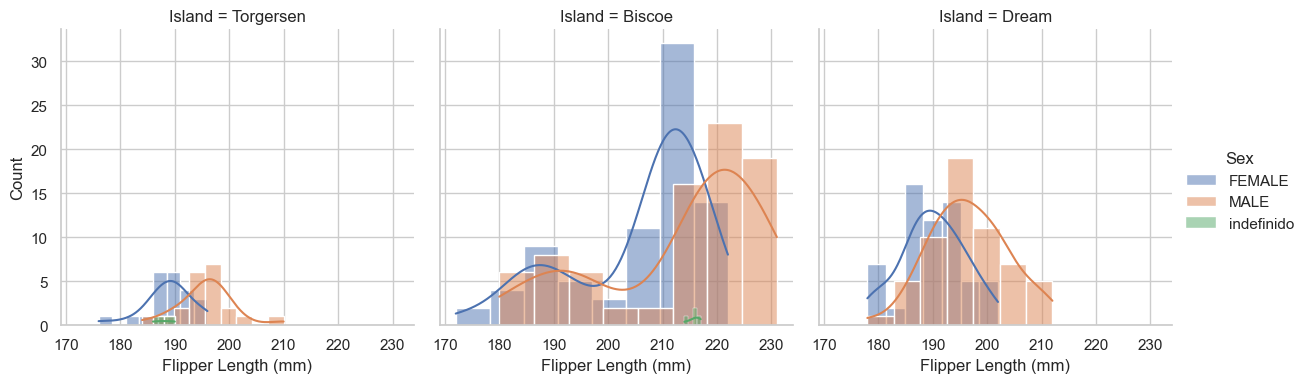

In [23]:
# Facet Grid: Subgráficos por categoría
g = sns.FacetGrid(df, col='Island', hue='Sex', height=4)
g.map(sns.histplot, 'Flipper Length (mm)', kde=True)
g.add_legend()
plt.show()


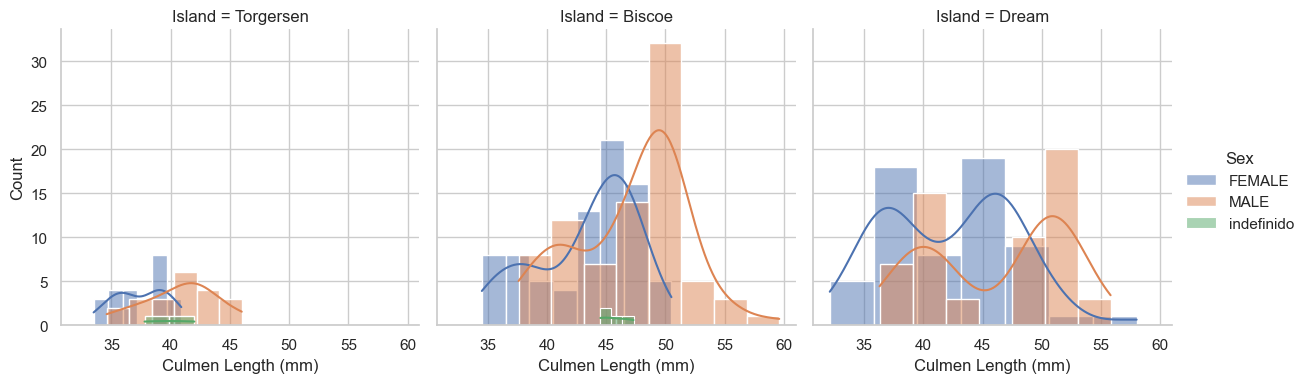

In [24]:
g = sns.FacetGrid(df, col='Island', hue='Sex', height=4)
g.map(sns.histplot, 'Culmen Length (mm)', kde=True)
g.add_legend()
plt.show()

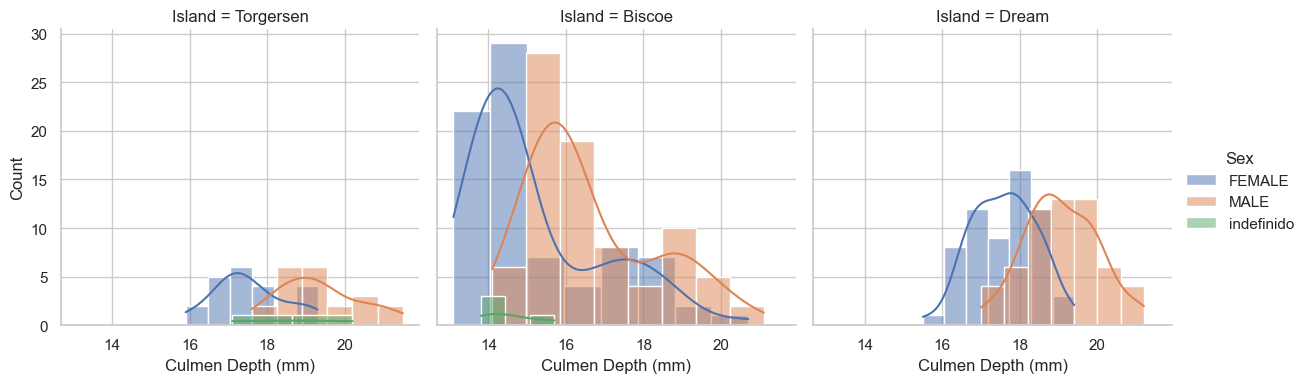

In [25]:
g = sns.FacetGrid(df, col='Island', hue='Sex', height=4)
g.map(sns.histplot, 'Culmen Depth (mm)', kde=True)
g.add_legend()
plt.show()

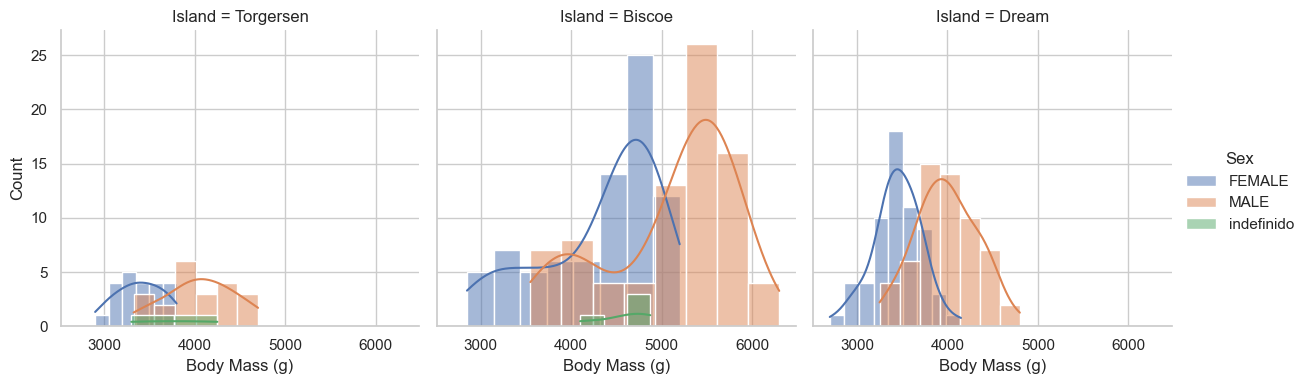

In [30]:
g = sns.FacetGrid(df, col='Island', hue='Sex', height=4)
g.map(sns.histplot, 'Body Mass (g)', kde=True)
g.add_legend()
plt.show()

# 1. Entender diferencias observables entre especies y su distribucion por isla.

1. Que especies predominan y como se distribuyen.
2. Que diferencias morfologicas relevantes aparecen entre especies.
3. Que variables son mas utiles para entender perfiles biologicos.


c:\Bootcam\Proyecto_Pinguinos\pinguinos\Lib\site-packages\seaborn\axisgrid.py:718: UserWarning: Using the countplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)


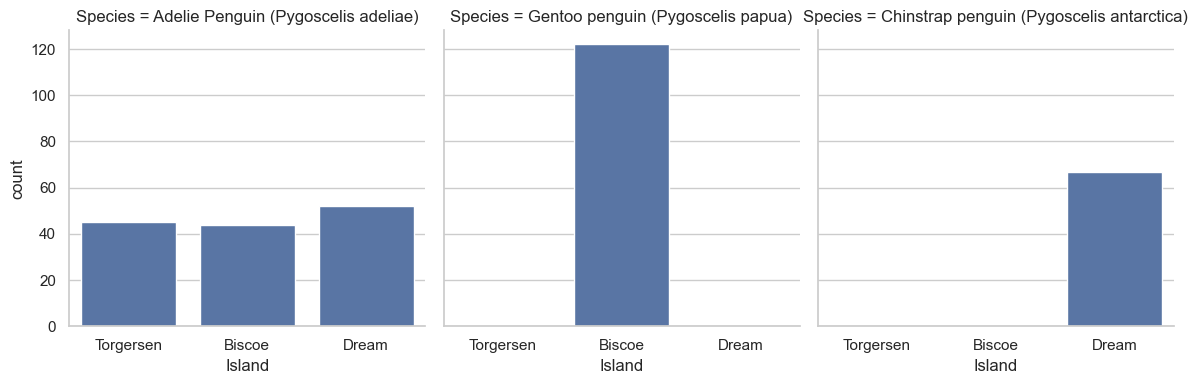

In [ ]:
## 1. Que especies predominan y como se distribuyen.

g = sns.FacetGrid(df, col='Species', height=4)
g.map(sns.countplot, 'Island')
plt.show()

# Esto responderia a: ### Estudio de relación de especie por isla (analisis bivariado)

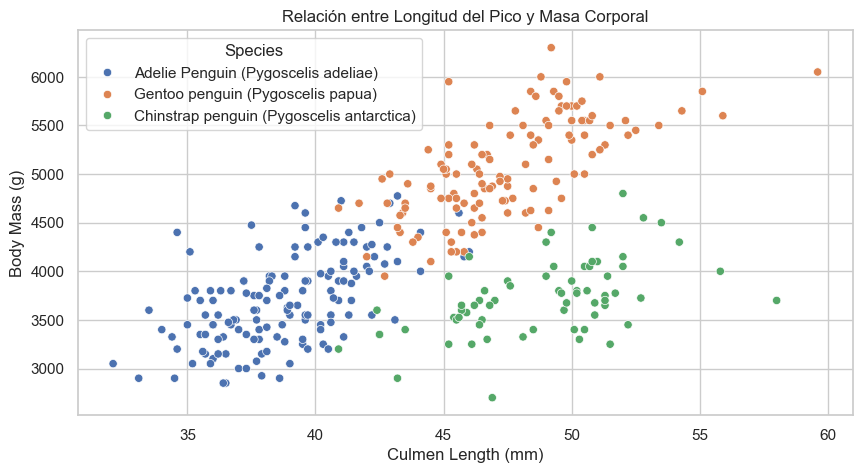

In [ ]:
# 2. Que diferencias morfologicas relevantes aparecen entre especies.

# Relación entre tamaño de pico y masa corporal (correlacion del bivariado)

sns.scatterplot(
    data=df,
    x='Culmen Length (mm)',
    y='Body Mass (g)',
    hue='Species'
)
plt.title('Relación entre Longitud del Pico y Masa Corporal')
plt.show()

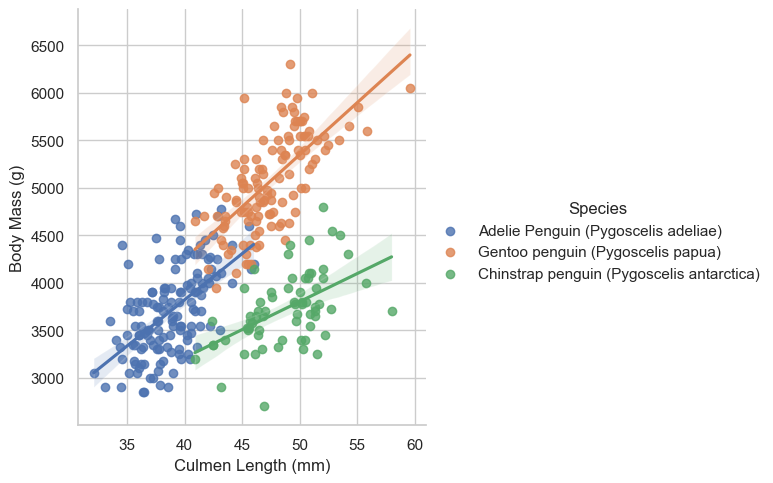

In [ ]:
# Relación entre tamaño de pico y masa corporal (correlacion del bivariado) FORMA 2

sns.lmplot(
    data=df,
    x='Culmen Length (mm)',
    y='Body Mass (g)',
    hue='Species'
)

"""Qué se ve claramente
✔ 1. Hay una correlación positiva
A medida que aumenta la longitud del pico, también aumenta la masa corporal.
Las líneas suben → relación positiva.
Esto coincide con el valor de correlación que calculaste.
✔ 2. Las especies forman grupos separados
Cada color representa una especie, y se agrupan de forma bastante clara:
Gentoo (naranja)
• 	Los puntos están más arriba y más a la derecha.
• 	Son los pingüinos más grandes y pesados.
• 	Tienen picos más largos y cuerpos más masivos.
Chinstrap (verde)
• 	Valores intermedios.
• 	Picos relativamente largos pero cuerpos menos pesados que los Gentoo.
Adelie (azul)
• 	Picos más cortos.
• 	Cuerpos más ligeros.
• 	Se agrupan abajo a la izquierda.
👉 Este gráfico muestra diferencias morfológicas muy claras entre especies.

Existe una correlación positiva entre la longitud del pico y la masa corporal. 
Además, las especies se separan claramente en el espacio morfológico: 
los Gentoo presentan mayor masa y picos más largos, los Chinstrap valores intermedios, 
y los Adelie menor tamaño y picos más cortos. 
Las líneas de regresión muestran que la relación entre ambas variables también varía entre especies, 
reflejando diferencias morfológicas relevantes
"""

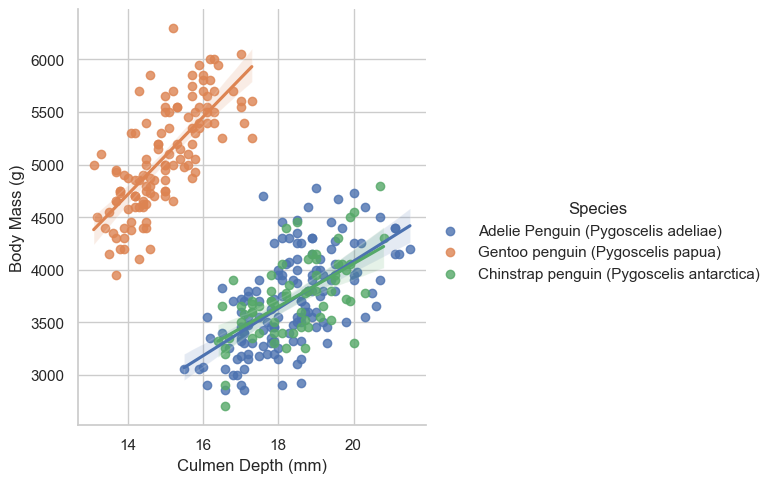

In [ ]:
# Relación entre grosor de pico y masa corporal

sns.lmplot(
    data=df,
    x='Culmen Depth (mm)',
    y='Body Mass (g)',
    hue='Species'
)

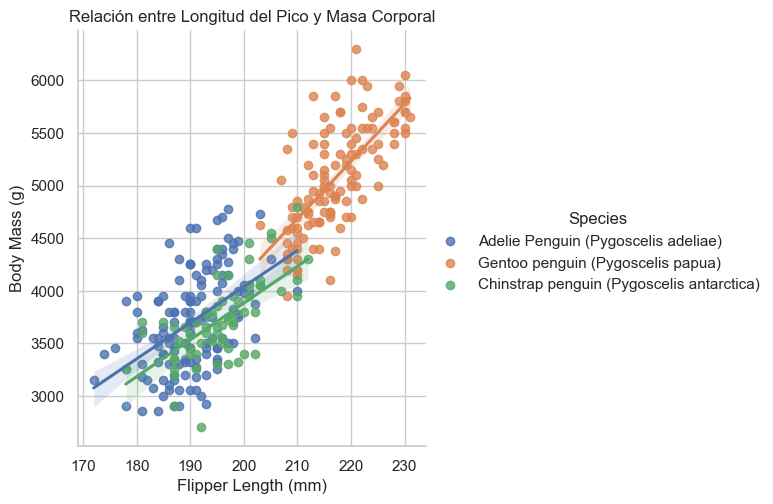

In [ ]:
# Relación entre tamaño de la aleta y masa corporal

sns.lmplot(
    data=df,
    x='Flipper Length (mm)',
    y='Body Mass (g)',
    hue='Species'
)
plt.title('Relación entre Longitud del Pico y Masa Corporal')
plt.show()

C:\Users\sarab\AppData\Local\Temp\ipykernel_21372\1218195538.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(


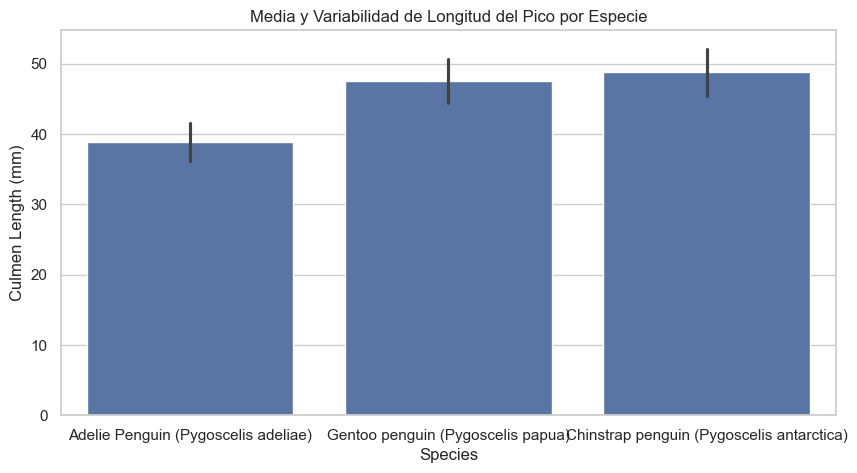

In [43]:
import seaborn as sns

sns.barplot(
    data=df,
    x='Species',
    y='Culmen Length (mm)',
    ci='sd'
)
plt.title('Media y Variabilidad de Longitud del Pico por Especie')
plt.show()

# Esto responde a Longitud del pico por especie

C:\Users\sarab\AppData\Local\Temp\ipykernel_21372\2317725448.py:1: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(


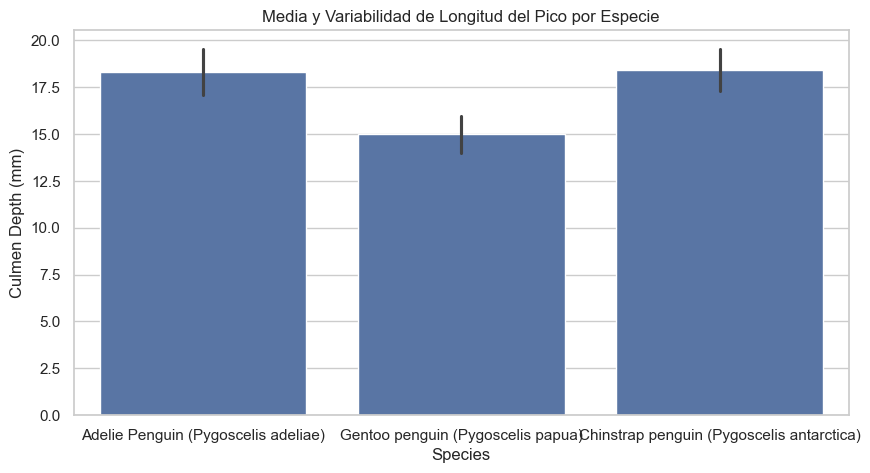

In [44]:
sns.barplot(
    data=df,
    x='Species',
    y='Culmen Depth (mm)',
    ci='sd'
)
plt.title('Media y Variabilidad de Longitud del Pico por Especie')
plt.show()

# Esto responde a: Grosor del pico por especie

C:\Users\sarab\AppData\Local\Temp\ipykernel_21372\1206796315.py:1: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(


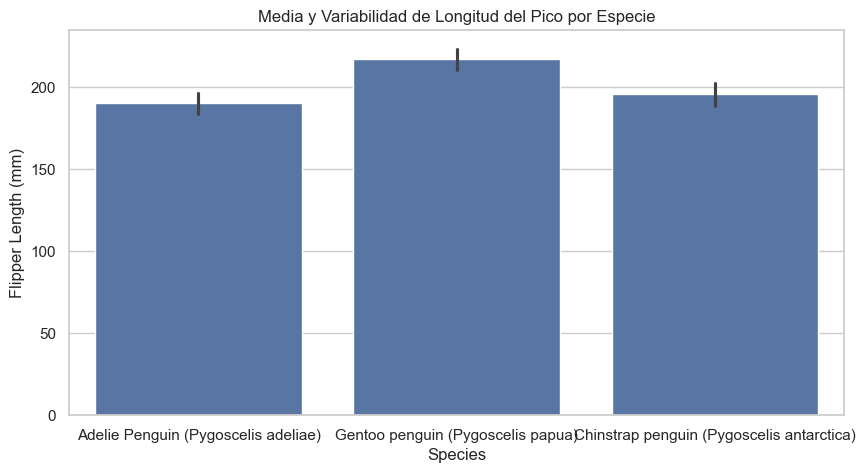

In [45]:
sns.barplot(
    data=df,
    x='Species',
    y='Flipper Length (mm)',
    ci='sd'
)
plt.title('Media y Variabilidad de Longitud del Pico por Especie')
plt.show()

# Esto responde a Longitud de las aletas por especie

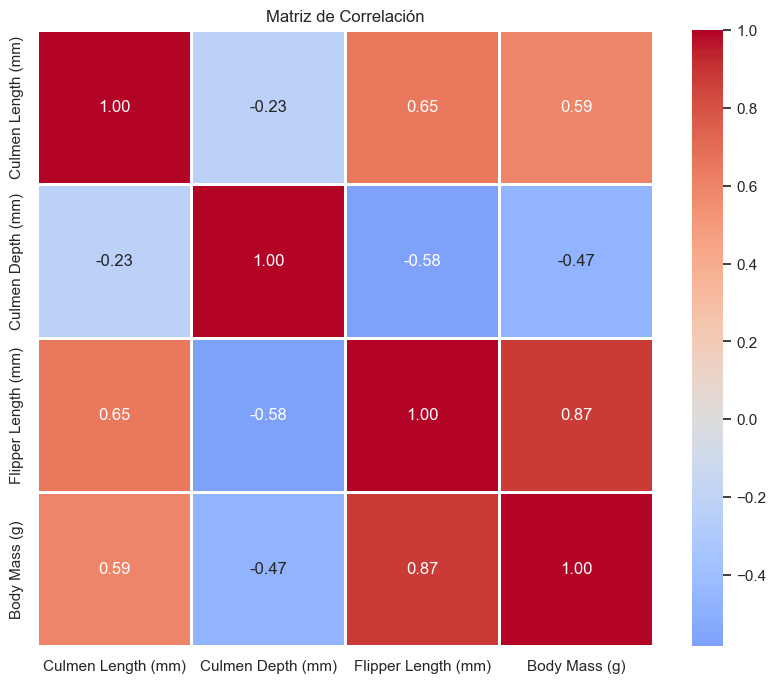

In [49]:
import numpy as np
# Solo numéricas
cols = ['Culmen Length (mm)', 'Culmen Depth (mm)', 'Flipper Length (mm)', "Body Mass (g)"]
corr = df[cols].corr()

# Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, fmt='.2f')
plt.title('Matriz de Correlación')
plt.show()